#### Porównanie metod inicjalizacji wag

In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [6]:
# parametry warstwy
input_dim = 100
output_dim = 100

In [12]:
# słownik metod inicjalizacji
init_methods = {
    "normal_(mean=0,std=0.1)": lambda w: nn.init.normal_(w, mean=0.0, std=0.1),
    "uniform_(-0.1,0.1)": lambda w: nn.init.uniform_(w, a=-0.1, b=0.1),
    "xavier_normal_": lambda w: nn.init.xavier_normal_(w),
    "kaiming_normal_": lambda w: nn.init.kaiming_normal_(w, nonlinearity='relu'),
    "orthogonal_": lambda w: nn.init.orthogonal_(w)
}

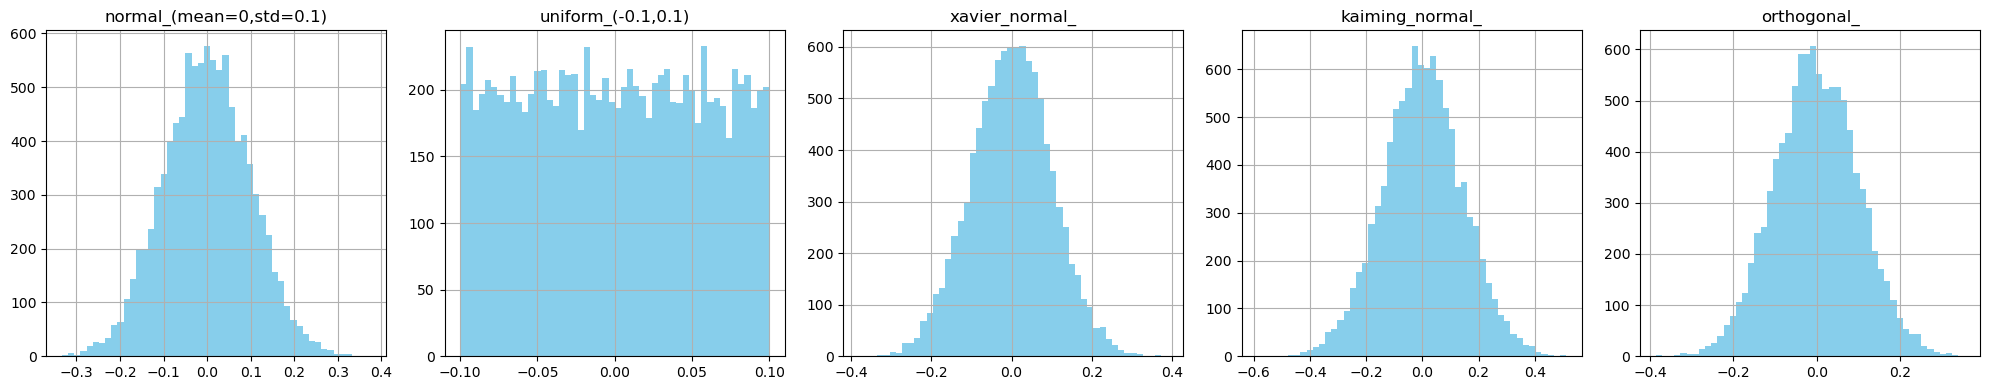

In [16]:
ig, axes = plt.subplots(1, 5, figsize=(20,4))

for ax, (name, init_fn) in zip(axes, init_methods.items()):
    # stwórz warstwę
    layer = nn.Linear(input_dim, output_dim)
    # inicjalizuj wagi
    init_fn(layer.weight)
    # pobierz wagi jako numpy
    weights = layer.weight.detach().numpy().flatten()
    # histogram
    ax.hist(weights, bins=50, color='skyblue')
    ax.set_title(name)
    ax.grid(True)

plt.tight_layout()
plt.show()